In [1]:

import numpy as np
import matplotlib.pyplot as plt
import DecayFitNet.python.toolbox.BayesianDecayAnalysis as bda
from DecayFitNet.python.toolbox.DecayFitNetToolbox import DecayFitNetToolbox

from slope2noise.utils import *

Here we are testing the code used to generate impulse responses by shaping white gaussian noise.   
The envelope is adjusted to match a target EDC, following the common slope model.  
First, define the T and A energy decay parameters (in the Schroeder backward integration sense)


In [2]:
T_s = np.array([[0.5, 1.5]])  # T60 in seconds
A_s = np.array([2, 0.1])   # decay model amplitude (energy)
n_slopes = T_s.shape[-1]
fs = 48000  # sampling frequency in Hz
L = 3*fs   # length of the impulse response in samples

time_axis = np.arange(0, L) / fs

### Target Energy Decay Curve 
Construct the EDC of the desired RIR from the T_s and A_s values

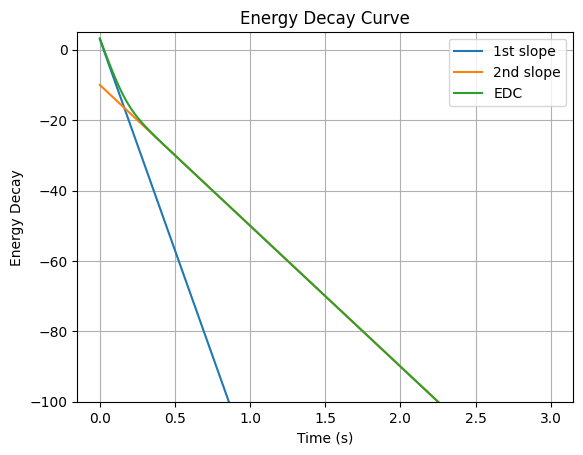

In [3]:
envelope_kernel = decay_kernel( T_s,
                                time_axis,
                                fs,
                                normalize_envelope=False,
                                add_noise=False)
edc = A_s*envelope_kernel
plt.plot(time_axis, 10*np.log10(edc[0, :, 0]), label='1st slope')
plt.plot(time_axis, 10*np.log10(edc[0, :, 1]), label='2nd slope')
plt.plot(time_axis, 10*np.log10(np.sum(edc[0, :, :], axis=-1)), label='EDC')
plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.legend()
plt.title('Energy Decay Curve')
plt.ylim([-100, 5])
plt.grid(True)
plt.show()

### Shaped Noise
Here the Schroeder T and A values are adapted and used to define the envelopes that are then used to shape the white gaussian noise sequence


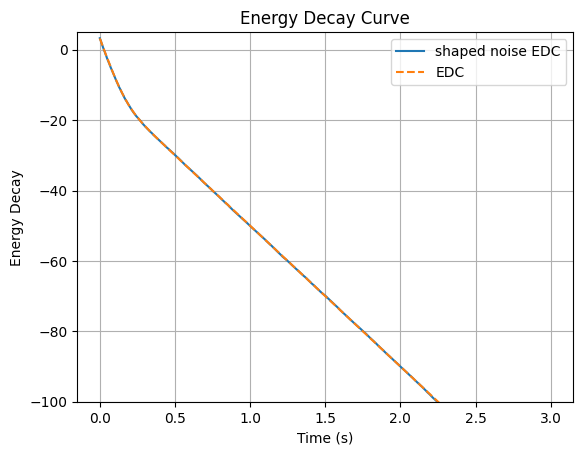

In [25]:
T_e = 2 * T_s
envelope_kernel = decay_kernel( T_e,
                                time_axis,
                                fs,
                                normalize_envelope=True,
                                add_noise=False)
gaussian_noise = np.random.randn(1, L, n_slopes)
shaped_noise = np.sqrt(A_s)*envelope_kernel*gaussian_noise
# use schroeder backward integration to get the EDC
sn_int = schroeder_backward_int(np.sum(shaped_noise, axis=-1), normalize=False)
plt.plot(time_axis, 10*np.log10(sn_int[0, :]), label='shaped noise EDC')
plt.plot(time_axis, 10*np.log10(np.sum(edc[0, :, :], axis=-1)), '--', label='EDC')
plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.legend()
plt.title('Energy Decay Curve')
plt.ylim([-100, 5])
plt.grid(True)
plt.show()

Let's double check with linear least squares that we are producing an RIR with correct A values.  
Let's also use BDA to confirm that the shaped noise has the target EDC. BDA estimated both T_s and A_s. 

In [26]:
A_ls = calculate_amplitudes_least_squares(T_s,
                                          fs,
                                          np.sum(shaped_noise, axis=-1, keepdims=True),
                                          f_bands=None,
                                          leave_out_ms=50.0,
                                          )

BDA = bda.BayesianDecayAnalysis(n_slopes,
                                fs,
                                filter_frequencies=None, )

# alternatively, you can use the DecayFitNetToolbox to estimate the EDC parameters
# decayfitnet = DecayFitNetToolbox(n_slopes,
#                                 fs,
#                                 filter_frequencies=None, )


edc_param, norm_vals = BDA.estimate_parameters(np.sum(shaped_noise,-1))

norm_vals = np.transpose(norm_vals)

# BDA takes the EDC parameters estimates for each band
T_bda, A_bda, N_bda = edc_param[0], edc_param[1], edc_param[2]

# amplitudes with least squares
print(
    f"Estimated T_BDA: \n {np.median(np.squeeze(np.round(T_bda, 3)), axis=0)}, \nA_BDA: \n {np.squeeze(np.round(A_bda, 3))} \n" \
    f"Estimated A_LS: {np.squeeze(np.round(A_ls, 3))} \n" \
    f"Reference T: {np.squeeze(np.round(T_s, 3))}, A: {np.squeeze(np.round(A_s, 3))}"
)
print(
    f"Noise level: \n {N_bda}")
print(
    f"Normalization values: \n {norm_vals}")

Estimated T_BDA: 
 [0.907 1.405], 
A_BDA: 
 [[0.081 0.061]
 [0.142 0.031]
 [0.017 0.115]
 [0.187 0.163]
 [0.215 0.002]
 [0.248 0.061]] 
Estimated A_LS: [1.392 0.054] 
Reference T: [0.5 1.5], A: [2.  0.1]
Noise level: 
 [[6.97934115e-14]
 [6.97934115e-14]
 [6.97934115e-14]
 [6.97934115e-14]
 [6.97934115e-14]
 [6.97934115e-14]]
Normalization values: 
 [[0.01429265]
 [0.01330061]
 [0.02823951]
 [0.05613785]
 [0.1206046 ]
 [0.24678967]]


Generate the EDC from the BDA estimations

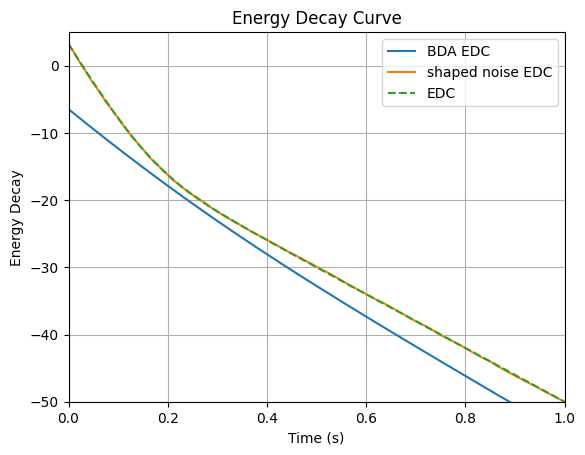

In [27]:
envelope_kernel = decay_kernel( np.median(np.squeeze(np.round(T_bda, 3)), axis=0).reshape(1, -1),
                                time_axis,
                                fs,
                                normalize_envelope=False,
                                add_noise=False)
edc_bda = np.median(np.squeeze(np.round(A_bda, 3)),axis=0) * envelope_kernel
# note, the median might not be the best choice here
plt.plot(time_axis, 10*np.log10(np.sum(edc_bda[0, :, :], axis=-1)), label='BDA EDC')
plt.plot(time_axis, 10*np.log10(sn_int[0, :]), label='shaped noise EDC')
plt.plot(time_axis, 10*np.log10(np.sum(edc[0, :, :], axis=-1)), '--', label='EDC')

plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.legend()
plt.ylim([-50, 5])
plt.xlim([0, 1])
plt.title('Energy Decay Curve')
plt.grid(True)
plt.show()

Ok, we don't have a perfect match. But note that the BDA estimates the EDC parameters per octave band, which might causes some differences if not synthesized properly.  
What if we "denormalize" the A values that BDA is estimating?  
Note that since we are working on synthetic data, the noise component is negligible 

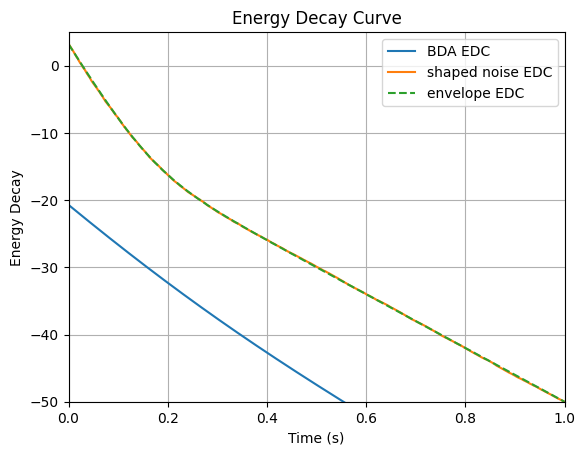

In [31]:
envelope_kernel = decay_kernel( np.median(np.squeeze(np.round(T_bda, 3)), axis=0).reshape(1, -1),
                                time_axis,
                                fs,
                                normalize_envelope=False,
                                add_noise=False)
edc_bda = np.median(np.squeeze(np.round(A_bda * norm_vals, 3)),axis=0) * envelope_kernel
plt.plot(time_axis, 10*np.log10(np.sum(edc_bda[0, :, :], axis=-1)), label='BDA EDC')
plt.plot(time_axis, 10*np.log10(sn_int[0, :]), label='shaped noise EDC')
plt.plot(time_axis, 10*np.log10(np.sum(edc[0, :, :], axis=-1)), '--', label='envelope EDC')

plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.legend()
plt.ylim([-50, 5])
plt.xlim([0, 1])
plt.title('Energy Decay Curve')
plt.grid(True)
plt.show()

Maybe we need to compensate for the energy of the octave filter bank? 
The results look much better if we do so! 

In [33]:
A_n = A_bda * norm_vals
# Estimate the energy of the octave filters
rirFBands, _ = octave_filtering([], 
                             fs, 
                             BDA.get_filter_frequencies(), 
                             ir_len=L,
                             get_filter_ir=True)
bandEnergy = np.expand_dims(sum(np.abs(rirFBands)**2, 0), -1)  
# initial level
A_n =  A_n / bandEnergy
print(A_n) 

[[0.53629945 0.40569086]
 [0.43607487 0.09394948]
 [0.05707271 0.37550031]
 [0.60829104 0.52906052]
 [0.75134713 0.00863867]
 [0.88421457 0.2190267 ]]


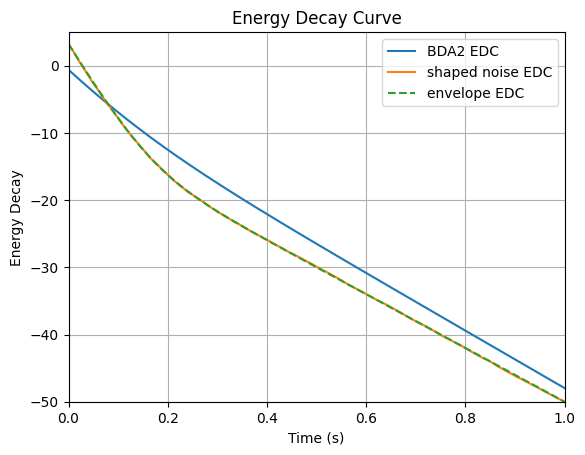

In [34]:
envelope_kernel = decay_kernel( np.median(np.squeeze(np.round(T, 3)), axis=0).reshape(1, -1),
                                time_axis,
                                fs,
                                normalize_envelope=False,
                                add_noise=False)
edc_bda = np.median(np.squeeze(np.round(A_n, 3)),axis=0) * envelope_kernel
# plt.plot(time_axis, 10*np.log10(edc_bda[0, :, 0]), label='1st slope')
# plt.plot(time_axis, 10*np.log10(edc_bda[0, :, 1]), label='2nd slope')
plt.plot(time_axis, 10*np.log10(np.sum(edc_bda[0, :, :], axis=-1)), label='BDA2 EDC')
plt.plot(time_axis, 10*np.log10(sn_int[0, :]), label='shaped noise EDC')
plt.plot(time_axis, 10*np.log10(np.sum(edc[0, :, :], axis=-1)), '--', label='envelope EDC')

plt.xlabel('Time (s)')
plt.ylabel('Energy Decay')
plt.legend()
plt.ylim([-50, 5])
plt.xlim([0, 1])
plt.title('Energy Decay Curve')
plt.grid(True)
plt.show()